In [58]:
# import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix


In [2]:
# load in the dataset
df = pd.read_csv('Telco-Customer-Churn.csv')

**Data Inspection**

In [3]:
# display the first ten rows of the dataset
print(df.head(10))

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL        

In [4]:
# output the names and data types of the dataset's columns
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**Data Preprocessing**

In [5]:
# convert the "TotalCharges" column to the numeric data type
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [6]:
# remove rows with missing values from the dataset
df = df.dropna()

In [7]:
# remove the "customerID" column from the dataset
df.drop("customerID", axis=1, inplace=True)

In [8]:
# convert the "Churn" column to binary numeric values
# replace "yes" with 1 and "no" with 0
df['Churn'] = df['Churn'].replace({
    'Yes': 1,
    'No': 0
}).astype(int)

In [9]:
# convert all categorical variables in the dataset into dummy
# variables - store the result in a new dataframe called
# telecom_cust_dummies

# also dropping first columns to avoid dummy trap
telecom_cust_dummies = pd.get_dummies(df, drop_first=True)

In [10]:
# display the new column titles
print(telecom_cust_dummies.info())

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   Churn                                  7032 non-null   int64  
 5   gender_Male                            7032 non-null   bool   
 6   Partner_Yes                            7032 non-null   bool   
 7   Dependents_Yes                         7032 non-null   bool   
 8   PhoneService_Yes                       7032 non-null   bool   
 9   MultipleLines_No phone service         7032 non-null   bool   
 10  MultipleLines_Yes                      7032 non-null   bool   
 11  InternetService_Fibe

**Data Visualisation**

<Axes: >

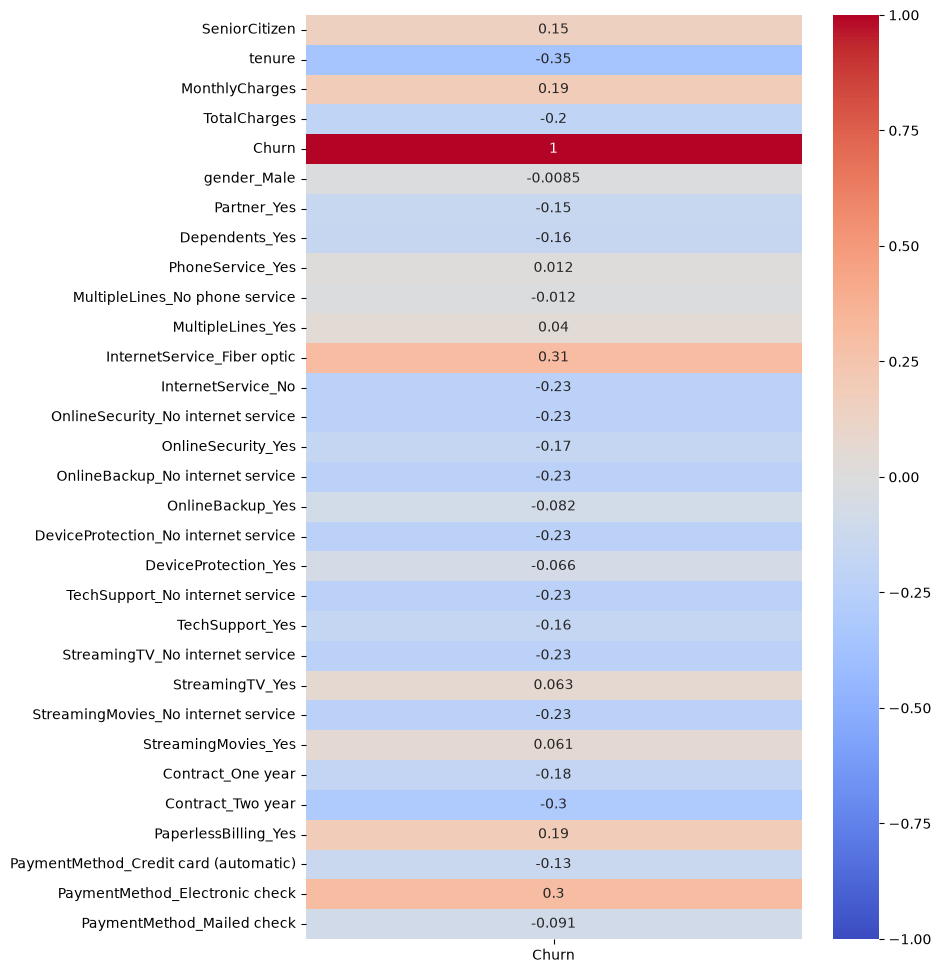

In [13]:
# create a correlation plot to visualise the correlation between
# features and the target variable "Churn"
churn_correlation =  telecom_cust_dummies.corr()[['Churn']]

plt.figure(figsize=(8, 12))

sns.heatmap(churn_correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

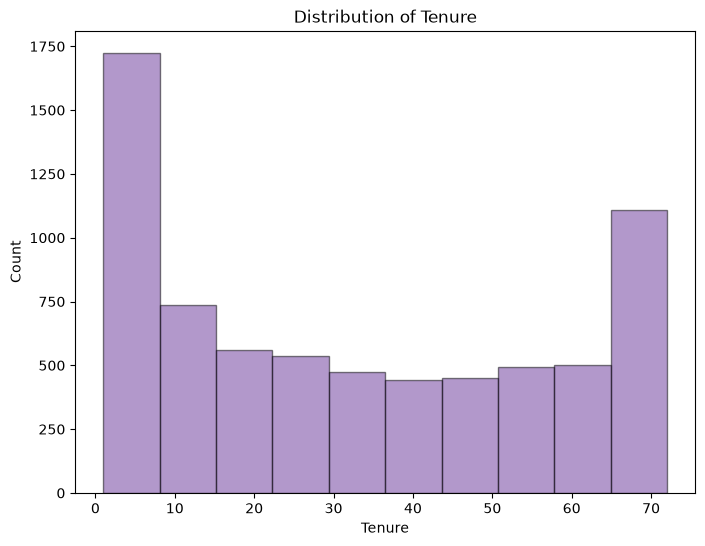

In [18]:
# create a histogram of the "tenure" column

plt.figure(figsize=(8,6))

plt.hist(telecom_cust_dummies['tenure'], 
         alpha=0.5,
         color='rebeccapurple',
        edgecolor = 'black')

plt.xlabel('Tenure')
plt.ylabel('Count')
plt.title('Distribution of Tenure') 
plt.show()

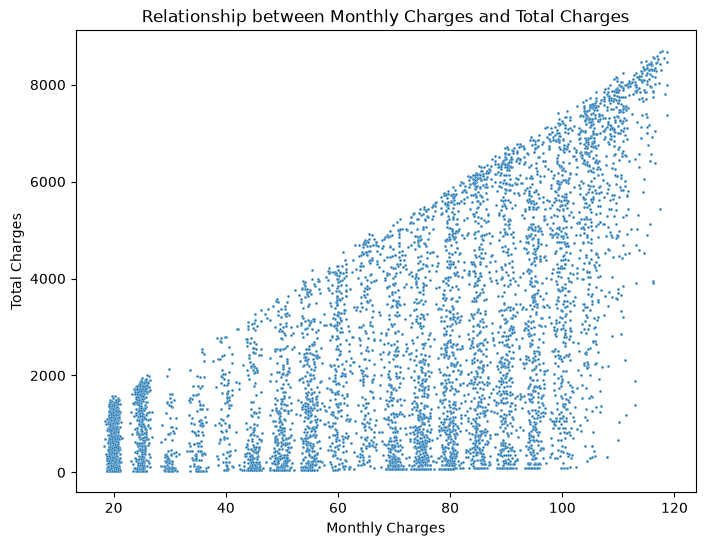

In [23]:
# create a scatter plot of "MonthlyCharges" vs "TotalCharges"

plt.figure(figsize=(8,6))

sns.scatterplot(data=telecom_cust_dummies,
                x='MonthlyCharges', 
                y='TotalCharges',
                s=4)

plt.title('Relationship between Monthly Charges and Total Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Total Charges')
plt.show()


Text(0.5, 1.0, 'Tenure of Churned and Non-Churned Customers')

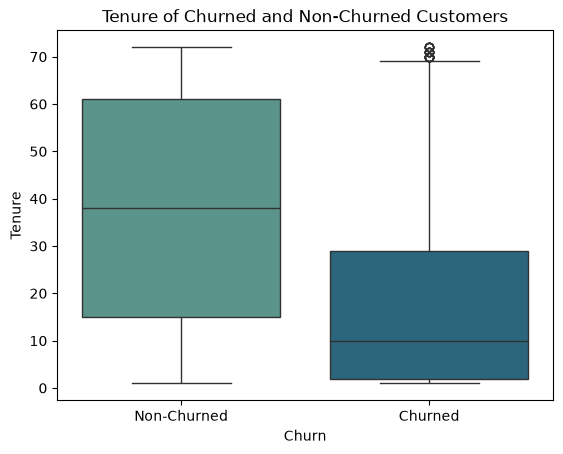

In [31]:
# create a box plot to compare "tenure" for churned and
# non-churned customers 

churn_mapping = {0: 'Non-Churned', 1: 'Churned'}

sns.boxplot(data=telecom_cust_dummies, 
            x=telecom_cust_dummies['Churn'].map(churn_mapping), 
            y='tenure',
            hue=telecom_cust_dummies['Churn'].map(churn_mapping),
            palette='crest')

plt.ylabel('Tenure')
plt.title('Tenure of Churned and Non-Churned Customers')

**Preparations for ML Training**

In [33]:
# scale all the variables to a range of 0 to 1
# using min-max scaling

scaler = MinMaxScaler()

scaled_data = pd.DataFrame(
    scaler.fit_transform(telecom_cust_dummies),
    columns = telecom_cust_dummies.columns
)

In [36]:
# split the dataset into training and test sets
# with a test size of 25%

X = scaled_data.drop(columns=['Churn'])
y = scaled_data['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

**Logistic Regression Model**

In [38]:
# import and train a logistic regression model on the training data
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [39]:
# make predictions on the test data
y_pred = log_reg.predict(X_test)

In [41]:
# calculate and print the accuracy score of the logistic
# regression model
print(f'Accuracy of logistic regression model:'
      f'{accuracy_score(y_test, y_pred)}')

Accuracy of logistic regression model:0.7912400455062572


**Random Forest Model**

In [45]:
# create a random forest classifier and tune the hyperparameters
rf = RandomForestClassifier(n_estimators = 2000,
                            oob_score = True,
                            max_features = "sqrt",
                            max_leaf_nodes = 50,
                            bootstrap = True
                           )          

In [46]:
# fit the model
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",2000
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",50
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_true, y_pred)` to use acustom metric. Only available if `bootstrap=True`.For an illustration of out-of-bag (OOB) error estimation, see the example:ref:`sphx_glr_auto_examples_ensemble_plot_ensemble_oob.py`.",True
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if

In [47]:
# make predictions on the new test data
y_pred_rf = rf.predict(X_test)

In [48]:
# calculate and print the accuracy score of the rfc
print(f'Accuracy of random forest model:'
      f'{accuracy_score(y_test, y_pred_rf)}')

Accuracy of random forest model:0.7918088737201365


In [50]:
# calculate and print the oob error estimation
oob_error = 1 - rf.oob_score_

print(f'OOB Error Estimation: {oob_error:.4f}')

OOB Error Estimation: 0.1925


The OOB Error Estimation of 0.1925 means the random forest model has an error rate of 19.25%. This indicates that the model is generalising to unseen data fairly well, correctly predicting 80.75% of the data.  

**Enhanced Model Evaluation**

In [56]:
# calculate the confusion matrix for the logistic regression model

classes = ['Non-Churned', 'Churned']

conf_mat_log = confusion_matrix(y_test, y_pred)

cml = pd.DataFrame(conf_mat_log, 
                   columns = classes,
                   index = classes)

print("Logistic Regression Confusion Matrix")
cml.index.name = 'Actual'
cml.columns.name = 'Predicted'
cml

Logistic Regression Confusion Matrix


Predicted,Non-Churned,Churned
Actual,,
Non-Churned,1154,146
Churned,221,237


The confusion matrix for the logistic regression model indicates that the model correctly predicted non-churned and churned data points more often than not, however was much better at correctly predicting non-churned data (88.77% correct) rather than churned data (51.75% correct).

In [57]:
# calculate the confusion matrix for the random forest model

conf_mat_rf = confusion_matrix(y_test, y_pred_rf)

cmrf = pd.DataFrame(conf_mat_rf, 
                   columns = classes,
                   index = classes)

print("Random Forest Confusion Matrix")
cmrf.index.name = 'Actual'
cmrf.columns.name = 'Predicted'
cmrf

Random Forest Confusion Matrix


Predicted,Non-Churned,Churned
Actual,,
Non-Churned,1184,116
Churned,250,208


The confusion matrix for the random forest model indicates that the model was much more likely to predict a data point to be non-churned, leading to 91.08% of non-churned data being correctly identified, but only 45.41% of churned data being correctly identified.

In [59]:
# compute the precision and recall scores for the
# logistic regression model
print(f'Precision of logistic regression model:'
      f'{precision_score(y_test, y_pred,
                        average="macro")}')
print(f'Recall of logistic regression model:'
      f'{recall_score(y_test, y_pred,
                     average="macro")}')

Precision of logistic regression model:0.7290358414431521
Recall of logistic regression model:0.7025797783003023


In [60]:
# compute the precision and recall scores for the
# random forest model
print(f'Precision of random forest model:'
      f'{precision_score(y_test, y_pred_rf,
                        average="macro")}')
print(f'Recall of random forest model:'
      f'{recall_score(y_test, y_pred_rf,
                     average="macro")}')

Precision of random forest model:0.7338188956041118
Recall of random forest model:0.6824588511924756


Precision scores tell us out of all predicted positives how many were real, and recall scores tell us out of all real positives how many the model found.

The precision and recall scores above show that both the logistic regression model and the random forest model performed marginally better in precision rather than recall, meaning they are relatively accurate in their positive predictions but still missed a portion of actual positive cases. 

The logistic regression model performed better in recall than the random forest model, but the random forest model performed better in precision.

After comparing the logistic regression and random forest models, for this task the logistic regression model would be the better choice. This is because it is more costly for a company to predict a customer to not churn when they end up churning rather than the other way round, meaning a higher recall value is more valuable than a higher precision value.